# ***Классификация тональности отзывов Amazon***

## Описание проекта 

Построение модели для автоматического определения тональности отзывов (позитивный/негативный) на основе текста

## Бизнес задача

Автоматизация обработки отзывов для быстрого выявления негативных отзывов и реагирования на проблемы клиентов

## Ключевые результаты 
- **Лучшая модель:** LogisticRegression(class_weight='balanced')
- **Accuracy: 88%**
- **F1-score (positive): 0.92** - отличное качество для позитивных отзывов
- **F1-score (negative): 0.75** - хорошее качество для негативных отзывов (с учетом дисбаланса)
- **Recall (negative): 83%** - находим 83% негативных отзывов
- **Recall (positive): 89%** - находим 89% позитивных отзывов

## Ключевые выводы 
- Только текст отзыва имеет предсказательную силу
- Другие признаки (полезность, время, длина) бесполезны
- Базовая логистическая регрессия оптимальна
- Данные сильно разреженные: 69% продуктов имеют всего 1 отзыв

## Структура проекта
- `notebooks/amazon_sentiment_analysis.ipynb` - полный анализ
- `models/log_model.pkl` - сохраненная модель
- `models/tfidf_text.pkl` - векторизатор для текста
- `models/tfidf_summary.pkl` - векторизатор для заголовков
- `results/predictions.csv` - предсказания на тестовой выборке

# 1. Импорт данных и предобработка

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

In [2]:
reviews = pd.read_csv('../data/Reviews.csv')

**Характеристики датасета:** 

Размер: 568,454 отзыва, 10 признаков 

**Описание признаков датасета:**

- Id - Номер строки в таблице 
- ProductId - Уникальный идентификатор продукта (товара). Всего 74,258 уникальных продуктов
- UserId - Уникальный идентификатор пользователя (кто оставил отзыв). Всего 256,059 уникальных пользователей
- ProfileName - Имя пользователя. Может повторяться у разных UserId
- HelpfulnessNumerator - Число пользователей, которые нашли отзыв ПОЛЕЗНЫМ (Из них сколько нажали "этот отзыв ПОЛЕЗЕН")
- HelpfulnessDenominator - Количество пользователей, указавших, нашли ли они отзыв полезным или нет (Сколько всего человек нажали кнопку "этот отзыв полезен/бесполезен") 
- Score - Оценка. Диапазон: 1-5 звёзд
- Time - Время создания отзыва 
- Summary - Краткое описание отзыва (заголовок)
- Text - Полный текст отзыва

**Предобработка датасета:**

Исходный датасет содержит 568,454 отзыва. Полный объем данных слишком велик для обработки на обычном компьютере  и приведет к длительному обучению моделей.

Для ускорения вычислений и возможности экспериментировать с разными моделями была взята случайная выборка из 30,000 отзывов. Выборка делается с фиксированным random_state=42 для воспроизводимости результатов - при повторном запуске кода будет получена та же выборка

reviews_sample = reviews.sample(n=30000, random_state=42)

In [3]:
reviews_sample = reviews.sample(n=30000, random_state=42)

In [4]:
reviews_sample

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
165256,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
231465,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
427827,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
433954,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
70260,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...
...,...,...,...,...,...,...,...,...,...,...
300103,300104,B007BENTO2,A1TRF1LYABI4X0,352pro,0,0,5,1348876800,"Thank you, Amazon! Zagnuts are the best!!","Thank you, Amazon! Oh my God, I can finally fi..."
124651,124652,B002OG4ZBS,A2PU1UGNR3E6B3,A. GRABER,1,1,5,1279756800,"small, but tasty",great snack. You can find these at whole food...
214557,214558,B001E48ASU,ABDYYDGJOU9XZ,Corey Hansen Joseph,7,7,5,1327536000,Great Harissa powder,I usually but Harissa as a paste but my refrig...
213587,213588,B00141OVJA,A2RVB98KMKIGUS,"Susan E. Wellhausen ""mamasue""",1,1,5,1238371200,Awesome,Great product. My dog thinks she is getting a...


# 2. Разведочный анализ данных (EDA)

In [5]:
reviews_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 165256 to 282784
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      30000 non-null  int64 
 1   ProductId               30000 non-null  object
 2   UserId                  30000 non-null  object
 3   ProfileName             30000 non-null  object
 4   HelpfulnessNumerator    30000 non-null  int64 
 5   HelpfulnessDenominator  30000 non-null  int64 
 6   Score                   30000 non-null  int64 
 7   Time                    30000 non-null  int64 
 8   Summary                 29999 non-null  object
 9   Text                    30000 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.5+ MB


## 2.1. Распределение оценок 

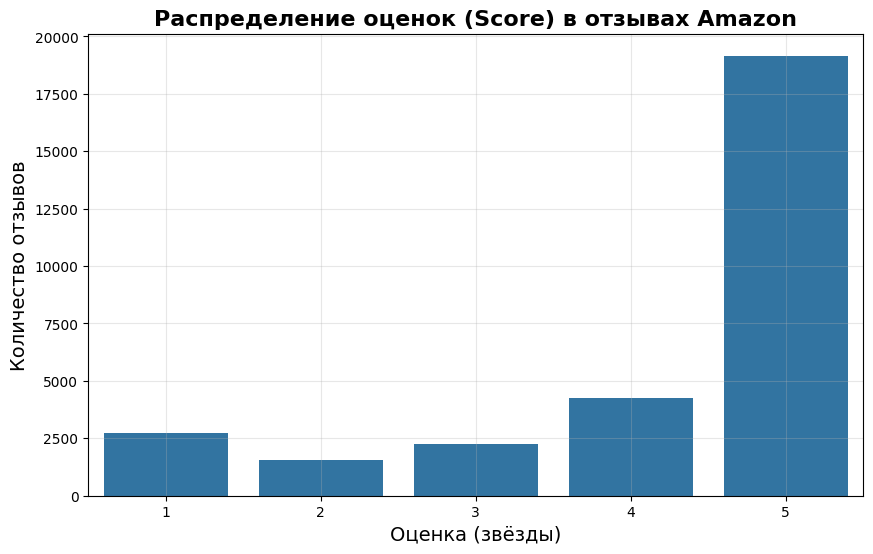

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=reviews_sample, x='Score')
plt.title('Распределение оценок (Score) в отзывах Amazon', fontsize=16, fontweight='bold')
plt.xlabel('Оценка (звёзды)', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.grid(alpha=0.3)

In [7]:
reviews_sample['Score'].value_counts()

Score
5    19160
4     4263
1     2734
3     2271
2     1572
Name: count, dtype: int64

---
**Выводы:**

Сильный дисбаланс классов - 78% отзывов положительные (4-5)

---

## 2.2. Анализ продуктов и пользователей 

In [8]:
top_products = reviews_sample.value_counts('ProductId')
top_10_products = reviews_sample.value_counts('ProductId').head(10)

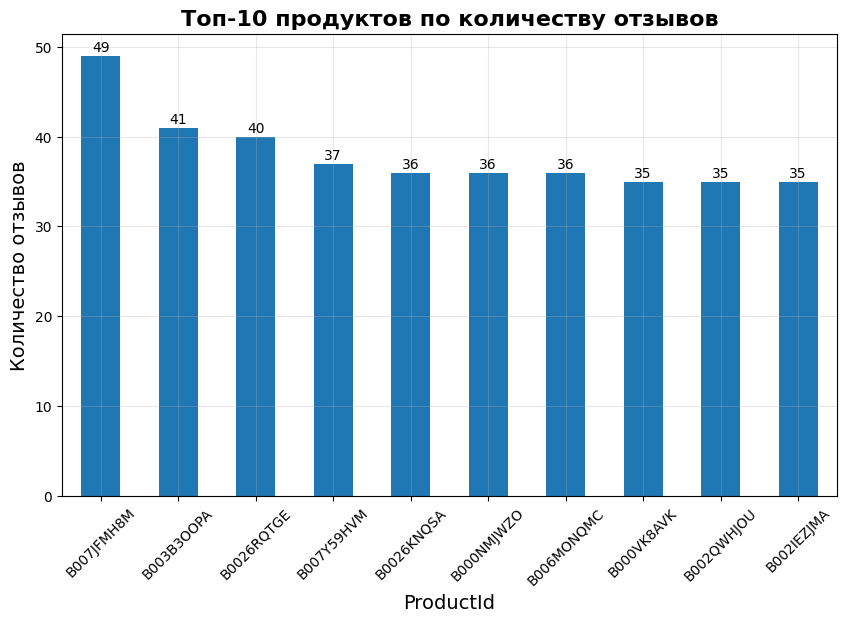

In [9]:
plt.figure(figsize=(10, 6))
top_10_products.plot(kind='bar')
plt.title('Топ-10 продуктов по количеству отзывов', fontsize=16, fontweight='bold')
plt.xlabel('ProductId', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

for i, v in enumerate(top_10_products):
    plt.text(i, v + 0.5, str(v), ha='center')

In [10]:
top_users = reviews_sample.value_counts('UserId')
top_10_users = reviews_sample.value_counts('UserId').head(10)

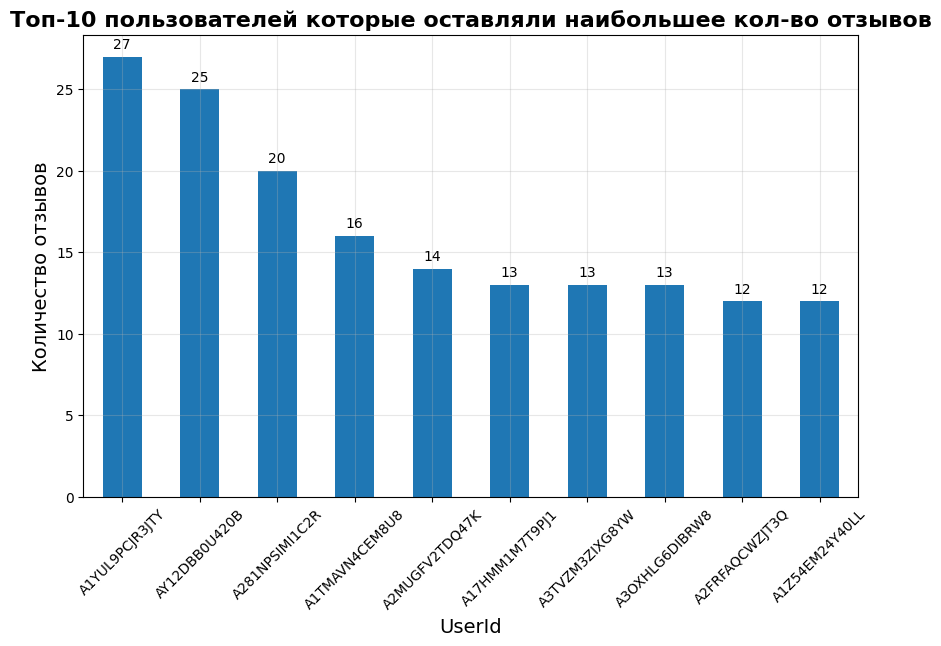

In [11]:
plt.figure(figsize=(10, 6))
top_10_users.plot(kind='bar')
plt.title('Топ-10 пользователей которые оставляли наибольшее кол-во отзывов', fontsize=16, fontweight='bold')
plt.xlabel('UserId', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

for i, v in enumerate(top_10_users):
    plt.text(i, v + 0.5, str(v), ha='center')

In [12]:
print('ВЫВОДЫ ИЗ АНАЛИЗА ПРОДУКТОВ И ПОЛЬЗОВАТЕЛЕЙ')

total_reviews = len(reviews_sample)
total_products = reviews_sample['ProductId'].nunique()
total_users = reviews_sample['UserId'].nunique()

products_one_review = sum(top_products[top_products == 1])
products_gt_10_reviews = (top_products >= 10).sum()

print(f'\nКлючевые метрики:')
print(f'Всего отзывов: {total_reviews}')
print(f'Уникальных продуктов: {total_products}')
print(f'Уникальных пользователей: {total_users}')
print(f'Среднее отзывов на продукт: {total_reviews/total_products:.2f}')
print(f'Среднее отзывов на пользователя: {total_reviews/total_users:.2f}')

print(f'\nАнализ продуктов')
print(f'Продуктов с 1 отзывом: {products_one_review} ({(products_one_review / total_products) * 100:.1f} %)')
print(f'Самый популярный продукт: {top_10_products.index[0]} ({top_10_products.iloc[0]} отзывов)')

print(f'\nАнализ пользователей:')
print(f'Самый активный пользователь: {top_users.index[0]} ({top_users.iloc[0]} отзывов)')
print(f'Топ-10 пользователей дали {top_10_users.sum()} отзывов ({top_10_users.sum()/total_reviews * 100:.1f}% от всех)')

ВЫВОДЫ ИЗ АНАЛИЗА ПРОДУКТОВ И ПОЛЬЗОВАТЕЛЕЙ

Ключевые метрики:
Всего отзывов: 30000
Уникальных продуктов: 14740
Уникальных пользователей: 25792
Среднее отзывов на продукт: 2.04
Среднее отзывов на пользователя: 1.16

Анализ продуктов
Продуктов с 1 отзывом: 10176 (69.0 %)
Самый популярный продукт: B007JFMH8M (49 отзывов)

Анализ пользователей:
Самый активный пользователь: A1YUL9PCJR3JTY (27 отзывов)
Топ-10 пользователей дали 165 отзывов (0.5% от всех)


---

**Вывод:**

Данные Amazon сильно разреженные:

- 69% продуктов имеют всего 1 отзыв
- В среднем продукт получает 2 отзыва
- Даже самый популярный продукт имеет только 49 отзывов

---

## 2.3. Анализ полезности отзывов 

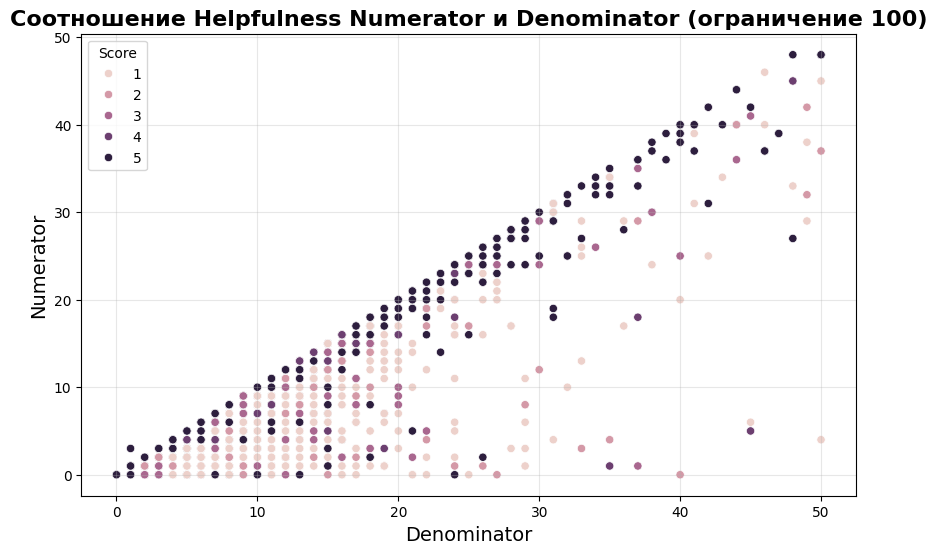

In [13]:
plt.figure(figsize=(10, 6))
filtered = reviews_sample[(reviews_sample['HelpfulnessDenominator'] <= 50)]
sns.scatterplot(data=filtered, x='HelpfulnessDenominator', y='HelpfulnessNumerator',  hue='Score')
plt.title('Соотношение Helpfulness Numerator и Denominator (ограничение 100)', fontsize=16, fontweight='bold')
plt.xlabel('Denominator', fontsize=14)
plt.ylabel('Numerator', fontsize=14)
plt.grid(alpha=0.3)

---
Гипотеза: 

Отзывы с высокими оценками (4-5 звёзд) чаще получают единогласное одобрение полезности (Numerator = Denominator)

---

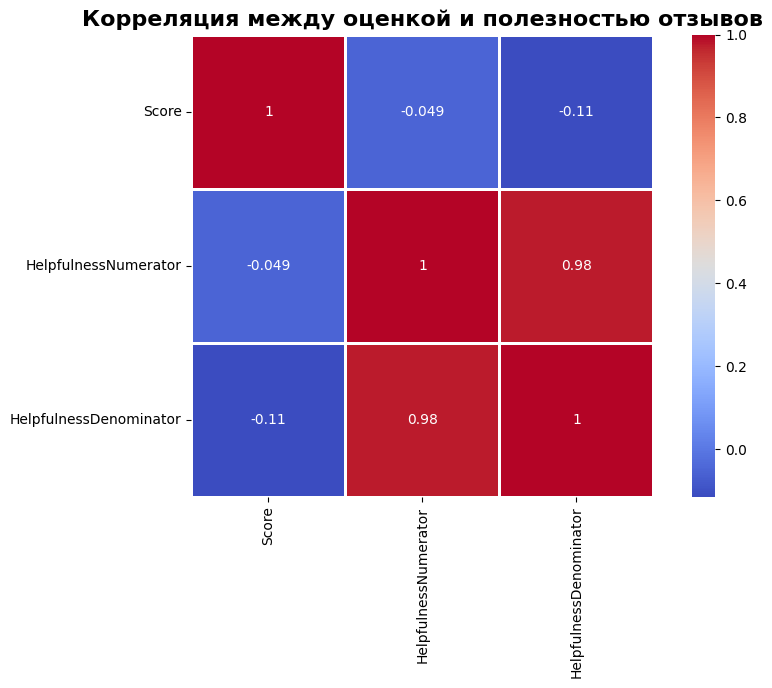

In [14]:
temp_df = reviews_sample[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator']].copy()

plt.figure(figsize=(10, 6))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm', linewidths=1, square=True)
plt.title('Корреляция между оценкой и полезностью отзывов', fontsize=16, fontweight='bold');

In [15]:
# Проверка гипотезы
# Создание признака "все нашли отзыв полезным"
reviews_sample['All_Found_Helpful'] = ((reviews_sample['HelpfulnessDenominator'] > 0) & (reviews_sample['HelpfulnessNumerator'] == reviews_sample['HelpfulnessDenominator'])).astype(int)

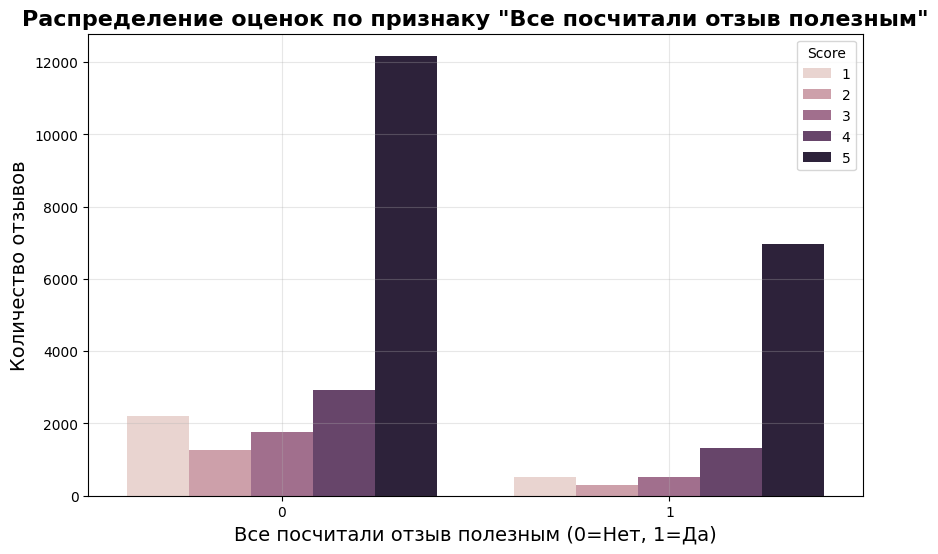

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=reviews_sample, x='All_Found_Helpful', hue='Score')
plt.title('Распределение оценок по признаку "Все посчитали отзыв полезным"', fontsize=16, fontweight='bold') 
plt.xlabel('Все посчитали отзыв полезным (0=Нет, 1=Да)', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.grid(alpha=0.3)

In [17]:
reviews_sample['Score'].corr(reviews_sample[ 'All_Found_Helpful'])

0.13593294844318587

---
Гипотеза: Отзывы с высокими оценками чаще получают 100% полезность

Результат: Гипотеза не подтверждается

Доказательства: 
- Корреляция Score и All_Found_Helpful: 0.136 (слабая)
- График наглядно демонстрирует: столбец оценки "5" высокий в обеих группах. Даже когда отзыв не получил 100% полезности, большинство всё равно имеют высший балл

Вывод: Полезность отзыва слабо связана с оценкой товара

---

## 2.4. Временной анализ 

In [18]:
reviews_sample['Time'] = pd.to_datetime(reviews_sample['Time'], unit='s')
reviews_sample['Time']

165256   2010-03-10
231465   2011-03-01
427827   2008-10-15
433954   2012-04-25
70260    2012-04-18
            ...    
300103   2012-09-29
124651   2010-07-22
214557   2012-01-26
213587   2009-03-30
282784   2010-09-18
Name: Time, Length: 30000, dtype: datetime64[ns]

In [19]:
reviews_sample['Year'] = reviews_sample['Time'].dt.year

In [20]:
year_counts = reviews_sample['Year'].value_counts().sort_index()

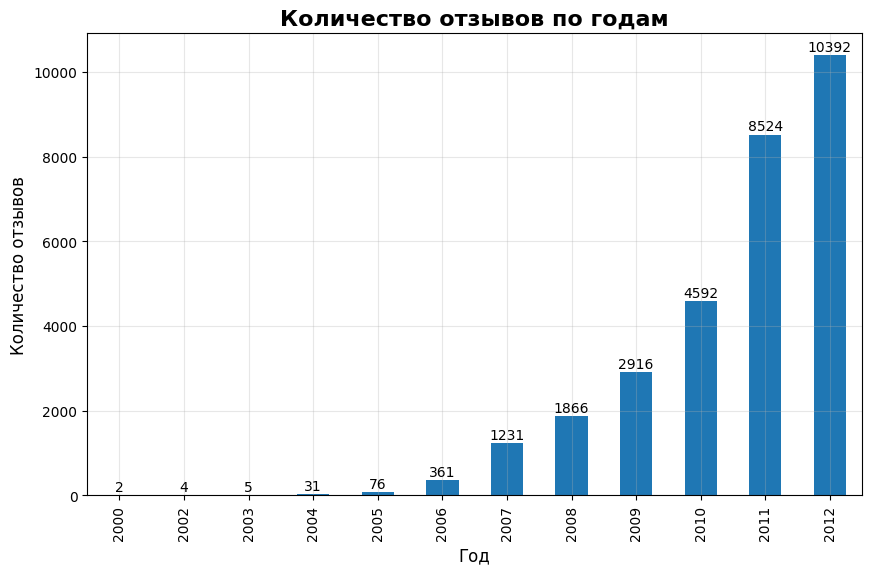

In [21]:
plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar')
plt.title('Количество отзывов по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество отзывов', fontsize=12)
plt.grid(alpha=0.3)

for i, v in enumerate(year_counts):
    plt.text(i, v + 100, str(v), ha='center')

In [22]:
avg_score_by_year = reviews_sample.groupby('Year')['Score'].mean()

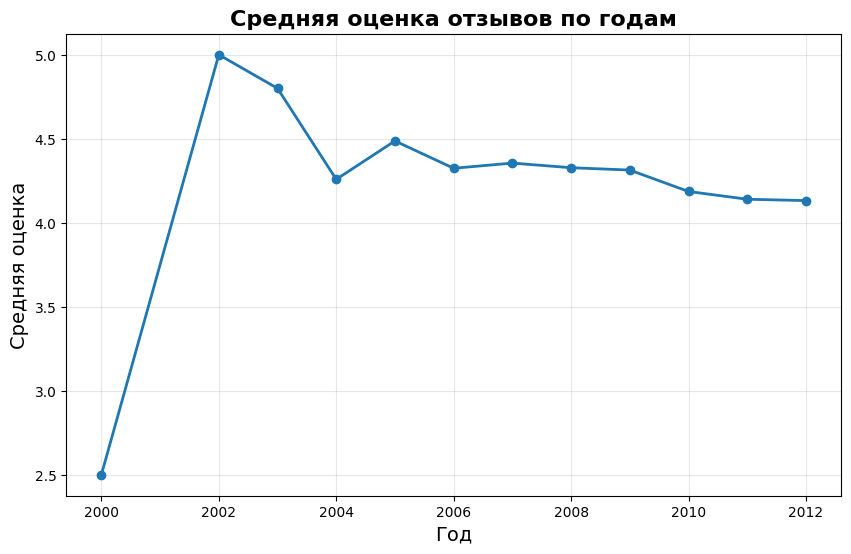

In [23]:
plt.figure(figsize=(10, 6))
avg_score_by_year.plot(marker='o', linewidth=2)
plt.title('Средняя оценка отзывов по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=14)
plt.ylabel('Средняя оценка', fontsize=14)
plt.grid(alpha=0.3)

---
**Вывод:**

Период данных: 2000-2012 годы

Рост активности: от 2 отзывов в 2000 до 10,392 в 2012

Средняя оценка снижается с 4.5 (2005) до 4.13 (2012)

Увеличение количества отзывов сопровождается небольшим снижением средних оценок

---

## 2.5. Анализ длины текста

In [24]:
reviews_sample['Text_Length'] = reviews_sample['Text'].str.len()

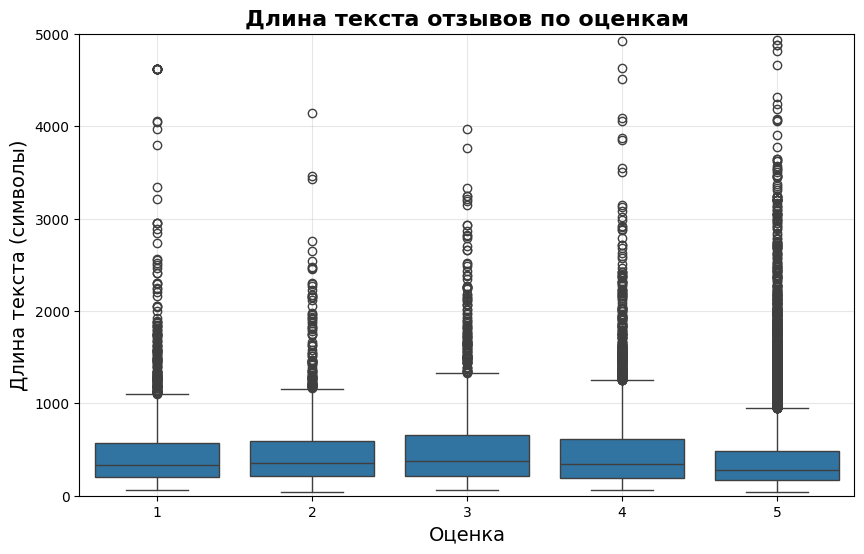

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=reviews_sample, x='Score', y='Text_Length')
plt.title('Длина текста отзывов по оценкам', fontsize=16, fontweight='bold')
plt.xlabel('Оценка', fontsize=14)
plt.ylabel('Длина текста (символы)', fontsize=14)
plt.ylim(0, 5000) 
plt.grid(alpha=0.3)

In [26]:
reviews_sample.groupby('Score')['Text_Length'].median()

Score
1    335.0
2    355.5
3    380.0
4    348.0
5    276.5
Name: Text_Length, dtype: float64

In [27]:
reviews_sample['Score'].corr(reviews_sample['Text_Length'])

-0.07211286630200475

---
**Вывод:**

Медианная длина по оценкам:
- Оценка 1: 335 символов
- Оценка 2: 356 символов  
- Оценка 3: 380 символов
- Оценка 4: 348 символов
- Оценка 5: 277 символов

Корреляция оценки и длины отзыва: -0.072

Вывод: Практически нет зависимости - разница медиан незначительна, корреляция близка к нулю (-0.072)

---

## 2.6. Итоговые выводы из EDA

1. Ключевые проблемы данных
   - Наблюдается выраженный дисбаланс классов: 78% отзывов имеют положительную оценку (4-5 звёзд)
   - Данные разреженные: 69% товаров имеют всего 1 отзыв, среднее - 2 отзыва на товар
   - Метаданные бесполезны: время, полезность отзыва, длина текста практически не коррелируют с оценкой
2. Стратегия классификации:

   На основе анализа выбрана бинарная классификация:
   
   - negative: оценки 1-3 (негативные и нейтральные отзывы)
   - positive: оценки 4-5 (положительные отзывы)
   - Нейтральный класс (оценка 3) исключён из-за размытых лексических маркеров и отсутствия чётких границ в данных
4. Главный вывод: Только текст отзыва имеет предсказательную силу. Все метаданные (полезность, время, длина текста) бесполезны для предсказания оценки

---

# 3. Подготовка данных к моделированию

## 3.1. Обработка пропущенных значений 

In [28]:
reviews_sample.isna().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
All_Found_Helpful         0
Year                      0
Text_Length               0
dtype: int64

In [29]:
reviews_sample[reviews_sample['Summary'].isna()]

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,All_Found_Helpful,Year,Text_Length
178290,178291,B00073IVAQ,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,2007-03-08,NaN,I only used two maybe three tea bags and got p...,0,2007,139


In [30]:
reviews_sample = reviews_sample.dropna()

## 3.2. Формирование целевой переменной

Исходная оценка Score имеет 5 градаций (1-5 звёзд), но для задачи классификации тональности достаточно бинарного разделения на положительные и отрицательные отзывы

Граница разделения:

- Оценки 1-3 - negative (негативные/нейтральные отзывы)
- Оценки 4-5 - positive (положительные отзывы)

Такой подход соответствует бизнес-логике Amazon, где отзывы с 4-5 звёздами считаются положительными, а с 1-3 звёздами - отрицательными

Альтернативный вариант с 3 классами (negative/neutral/positive) был рассмотрен в EDA, но нейтральный класс (оценка 3) плохо отделяется и ухудшает качество модели. Бинарная классификация даёт более устойчивые и интерпретируемые результаты

In [31]:
# Группировка Score на два класса
reviews_sample['Score_Cat'] = pd.cut(reviews_sample['Score'], bins=[0, 3, 5], 
                                     labels=['negative', 'positive'])

## 3.3. Удаление бесполезных признаков 

In [32]:
to_drop = ['Id', 'ProductId', 'UserId', 'ProfileName', 'Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time', 'All_Found_Helpful', 'Year','Text_Length']

reviews_sample = reviews_sample.drop(to_drop, axis=1)

In [33]:
reviews_sample.head()

,Summary,Text,Score_Cat
165256,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...,positive
231465,great kitty treats,My cat loves these treats. If ever I can't fin...,positive
427827,COFFEE TASTE,A little less than I expected. It tends to ha...,negative
433954,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin...",negative
70260,Great Taste . . .,and I want to congratulate the graphic artist ...,positive


---
На основе выводов EDA было установлено, что все не текстовые признаки (полезность отзыва, год, длина текста и др.) имеют крайне слабую корреляцию с целевой переменной (Score_Cat) и не несут полезной информации для предсказания тональности

Корреляции с оценкой:
- HelpfulnessNumerator: -0.05
- HelpfulnessDenominator: -0.11  
- All_Found_Helpful: 0.14
- Year: незначительные колебания
- Text_Length: -0.07

В связи с этим данные признаки были удалены. Финальный набор признаков состоит только из текстовых полей Summary и Text, что полностью соответствует главному выводу EDA: только текст отзыва имеет предсказательную силу

---

## 3.4. Анализ текста (частотный анализ слов) 

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

In [35]:
for sentiment in ['positive', 'negative']:
    cv = CountVectorizer(stop_words='english')
    matrix = cv.fit_transform(reviews_sample[reviews_sample['Score_Cat'] == sentiment]['Summary'])
    freqs = zip(cv.get_feature_names_out(), matrix.sum(axis=0).tolist()[0])
    top_words = [word for word, count in sorted(freqs, key=lambda x: -x[1])[:10]]
    print(f'{sentiment}: {top_words}')

positive: ['great', 'good', 'best', 'love', 'coffee', 'tea', 'delicious', 'product', 'excellent', 'taste']
negative: ['good', 'taste', 'like', 'great', 'product', 'flavor', 'coffee', 'bad', 'tea', 'ok']


---
**Вывод:**

Положительные отзывы: great, good, best, love, coffee, tea, delicious, product, excellent, taste

Отрицательные отзывы: good, taste, like, great, product, flavor, coffee, bad, tea, ok

1. Уникальные слова-маркеры:
   - Положительные: best, love, delicious, excellent
   - Отрицательные: bad, like, flavor, ok

2. Общие слова (встречаются в обоих классах):
   - good, great, coffee, tea, product, taste
   - TF-IDF автоматически снизит их вес, потому что они часто встречаются 
     и в положительных, и в отрицательных отзывах

3. Вывод для модели:
   - У каждого класса достаточно слов-маркеров для обучения
   - TF-IDF сам разберется с общими словами, снизив их значимость
   - Основной фокус при обучении будет на уникальных словах (best, love, bad и т.д.)

---

## 3.5. Разделение на train и test 

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = reviews_sample.drop('Score_Cat', axis=1)
y = reviews_sample['Score_Cat']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [39]:
print(f"Train: {X_train.shape[0]} отзывов")
print(f"Test: {X_test.shape[0]} отзывов")

Train: 20999 отзывов
Test: 9000 отзывов


## 3.6. Векторизация текста (TF-IDF)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

In [41]:
tfidf_summary = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_summary = tfidf_summary.fit_transform(X_train['Summary'])
X_test_summary = tfidf_summary.transform(X_test['Summary'])

In [42]:
tfidf_text = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_text = tfidf_text.fit_transform(X_train['Text'])
X_test_text = tfidf_text.transform(X_test['Text'])

In [43]:
from scipy.sparse import hstack

In [44]:
X_train_final = hstack([X_train_text, X_train_summary])
X_test_final = hstack([X_test_text, X_test_summary])

In [45]:
print(f"Форма для обучения: {X_train_final.shape}")
print(f"Форма для тестирования: {X_test_final.shape}")

Форма для обучения: (20999, 10000)
Форма для тестирования: (9000, 10000)


# 4. Построение и оценка моделей 

In [46]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

In [47]:
nb_model = MultinomialNB()
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
forest_model = RandomForestClassifier(class_weight='balanced')
linearSVC_model = LinearSVC(class_weight='balanced')

In [48]:
def report(model):
    model.fit(X_train_final, y_train)
    predictions = model.predict(X_test_final)
    print(classification_report(y_test, predictions))
    ConfusionMatrixDisplay.from_predictions(y_test, predictions)

## 4.1. Naive Bayes

              precision    recall  f1-score   support

    negative       0.87      0.48      0.62      1980
    positive       0.87      0.98      0.92      7020

    accuracy                           0.87      9000
   macro avg       0.87      0.73      0.77      9000
weighted avg       0.87      0.87      0.85      9000



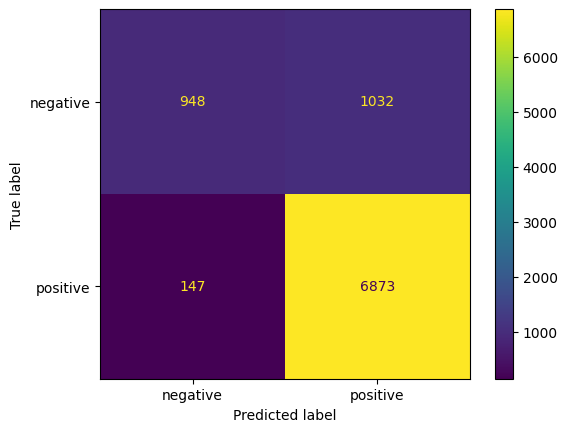

In [49]:
report(nb_model)

---
Результаты: 

- Accuracy: 87%
- Класс positive: отлично (recall 98%)
- Класс negative: плохо (recall 48%)

Матрица ошибок показывает что 1032 негативных отзыва ошибочно классифицированы как позитивные

Вывод: Наивный Байес сильно смещен в сторону мажорного класса. Не подходит для несбалансированных данных

---

## 4.2. Логистическая регрессия (базовая)

              precision    recall  f1-score   support

    negative       0.68      0.83      0.75      1980
    positive       0.95      0.89      0.92      7020

    accuracy                           0.88      9000
   macro avg       0.81      0.86      0.83      9000
weighted avg       0.89      0.88      0.88      9000



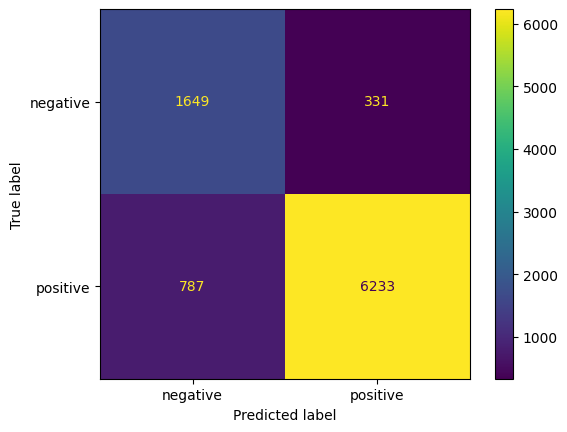

In [66]:
report(log_model)

---
Результаты: 

- Accuracy: 88%
- Класс positive: F1=0.75 (recall 83%)
- Класс negative: F1=0.92 (recall 89%)
Матрица ошибок показывает что ошибки распределены равномернее 

Вывод: Лучший баланс между классами. class_weight='balanced' работает эффективно

---

## 4.3. Random Forest

              precision    recall  f1-score   support

    negative       0.85      0.49      0.63      1980
    positive       0.87      0.98      0.92      7020

    accuracy                           0.87      9000
   macro avg       0.86      0.74      0.77      9000
weighted avg       0.87      0.87      0.86      9000



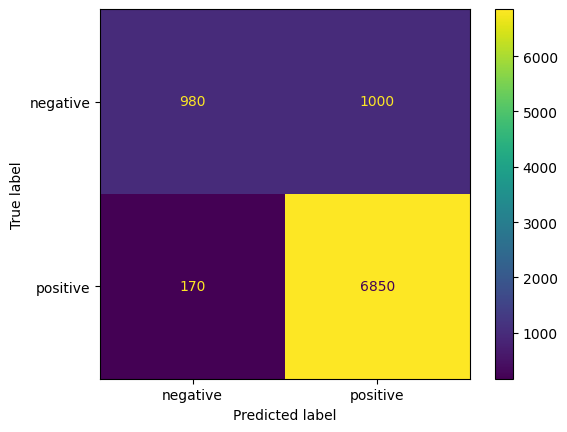

In [51]:
report(forest_model)

---
Результаты: 

- Accuracy: 87%
- Negative: F1=0.62 (recall 49% - плохо)
- Positive: F1=0.92 (recall 97%)

Матрица ошибок показывает что 1002 негативных отзыва ошибочно классифицированы как позитивные

Вывод: Random Forest переобучается на мажорном классе. Не подходит

---

## 4.4. LinearSVC 

              precision    recall  f1-score   support

    negative       0.68      0.77      0.72      1980
    positive       0.93      0.90      0.92      7020

    accuracy                           0.87      9000
   macro avg       0.81      0.83      0.82      9000
weighted avg       0.88      0.87      0.87      9000



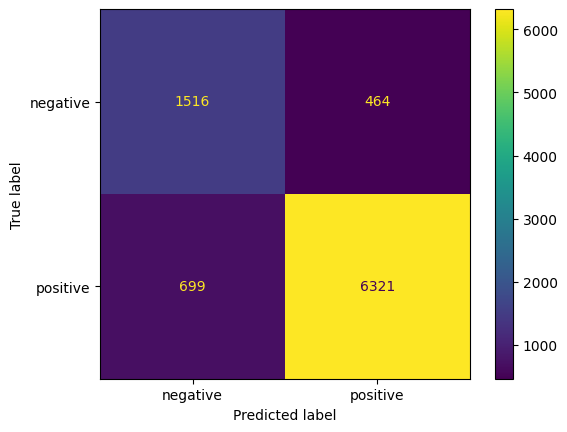

In [52]:
report(linearSVC_model)

---
Результаты: 

- Accuracy: 87%
- Negative: F1=0.72 (recall 77%)
- Positive: F1=0.92 (recall 90%)

Чуть хуже LogReg по негативному классу

Вывод: LinearSVC дает результат, близкий к LogReg, но немного уступает.

---

## 4.5. Подбор гиперпараметров для логистической регрессии (GridSearchCV)

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
param_grid = {
    'penalty':['l1', 'l2'],
    'C': [0.1, 1, 10, 100]
}

In [55]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [56]:
grid_model = GridSearchCV(
    estimator=log_model, 
    param_grid=param_grid,
)

              precision    recall  f1-score   support

    negative       0.69      0.77      0.73      1980
    positive       0.93      0.90      0.92      7020

    accuracy                           0.87      9000
   macro avg       0.81      0.84      0.82      9000
weighted avg       0.88      0.87      0.88      9000



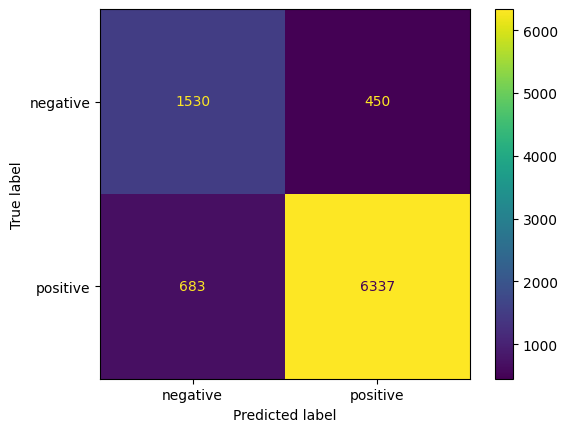

In [57]:
report(grid_model)

In [58]:
print("Лучшие параметры:", grid_model.best_params_)

Лучшие параметры: {'C': 10, 'penalty': 'l2'}


---
Результат: 

- Лучшие параметры: {'C': 10, 'penalty': 'l2'}
- Метрики на тестовой выборке: accuracy 87% (на 1% ниже базовой модели)

Логистическая регрессия с параметрами по умолчаню (C=1, penalty='l2') дала результат лучше, чем модель с настроенными гиперпараметрами 

1. Базовая модель уже оптимальна
2. Более сложная модель (с C=10) склонна к переобучению
3. GridSearchCV не гарантирует улучшение на тестовых данных

---

# 5. Итоговые результаты 
## 5.1. Сравнение моделей

In [59]:
import pandas as pd

results_df = pd.DataFrame({
    'Модель': ['Naive Bayes', 'Logistic Regression (С=1)', 'Logistic Regression (C=10)', 'Random Forest', 'LinearSVC'],
    
    'Accuracy': [0.87, 0.88, 0.87, 0.87, 0.87],

    'F1 (neg)': [0.62, 0.75, 0.73, 0.62, 0.72],
    'Recall (neg)': [0.48, 0.83, 0.77, 0.49, 0.77],
    'Precision (neg)': [0.87, 0.68, 0.69, 0.84, 0.68],
    
    'F1 (pos)': [0.92, 0.92, 0.92, 0.92, 0.92],
    'Recall (pos)': [0.98, 0.89, 0.90, 0.97, 0.90],
    'Precision (pos)': [0.87, 0.95, 0.93, 0.87, 0.93]
})

In [60]:
results_df

,Модель,Accuracy,F1 (neg),Recall (neg),Precision (neg),F1 (pos),Recall (pos),Precision (pos)
0,Naive Bayes,0.87,0.62,0.48,0.87,0.92,0.98,0.87
1,Logistic Regression (С=1),0.88,0.75,0.83,0.68,0.92,0.89,0.95
2,Logistic Regression (C=10),0.87,0.73,0.77,0.69,0.92,0.90,0.93
3,Random Forest,0.87,0.62,0.49,0.84,0.92,0.97,0.87
4,LinearSVC,0.87,0.72,0.77,0.68,0.92,0.90,0.93


## 5.2. Лучшая модель 

Лучшая модель: LogisticRegression(class_weight='balanced')

Метрики на тестовой выборке:
- Accuracy: 88%
- F1-score (negative): 0.75
- F1-score (positive): 0.92

Модель хорошо определяет положительные отзывы (98% recall) и значительно лучше конкурентов определяет отрицательные (83% recall)


## 5.3. Заключение 

В ходе экспериментов были протестированы различные модели классификации:

- Naive Bayes и Random Forest показали сильное смещение в пользу мажорного класса (recall на негативных отзывах 48-49%)
- LinearSVC близок по качеству к логистической регрессии, но уступает по recall на негативных отзывах (77% против 83%)
- Logistic Regression с параметрами по умолчанию (C=1) показала наилучший результат: F1-negative = 0.75, recall-negative = 83%
- Logistic Regression с гиперпараметрами (C=10), подобранными через GridSearchCV, показала результат хуже базовой версии (F1=0.73 против 0.75)

Это подтверждает, что:
- Базовая логистическая регрессия оптимальна для данной задачи
- Увеличение параметра C приводит к переобучению
- GridSearchCV не всегда улучшает результат на тестовых данных

Финальная модель (LogisticRegression с class_weight='balanced' и C=1) готова к использованию для классификации тональности отзывов Amazon.

# 6. Сохранение модели и результатов 

In [61]:
import joblib

In [62]:
best_model = {
    'model': log_model,
    'model_type': 'LogisticRegression',
    'params': {
        'C': 1,
        'penalty': 'l2',
        'class_weight': 'balanced'
    }
}

In [63]:
joblib.dump(best_model, '../models/log_model.pkl')

['../models/log_model.pkl']

In [64]:
joblib.dump(tfidf_text, '../models/tfidf_text.pkl')
joblib.dump(tfidf_summary, '../models/tfidf_summary.pkl')

['../models/tfidf_summary.pkl']

In [67]:
predictions_df = pd.DataFrame({
    'text': X_test['Text'].values,
    'summary': X_test['Summary'].values,
    'actual': y_test.values,
    'predicted': log_model.predict(X_test_final),
})

In [68]:
predictions_df.to_csv('../results/predictions.csv', index=False, encoding='utf-8')